# SSL-предобучения (BigP3BCI → 1D U-Net masked reconstruction)

## Путь к zarr

In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 6.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 86.2 MB/s eta 0:00:00:00:010:01


In [ ]:
import os, glob
print(glob.glob("/kaggle/input/*/*"))

In [ ]:
src = "/kaggle/input/datasets/taisiyaglazova/ssl-bigp3bci-zarr"
dst = "/kaggle/working/SSL_BigP3BCI.zarr"

shutil.copytree(src, dst)

print("Copied!")
!ls /kaggle/working

In [6]:
zarr_path = "/kaggle/working/SSL_BigP3BCI.zarr/ssl_bigp3bci.zarr"

import zarr
root = zarr.open(zarr_path, mode="r")
print(root["X"].shape)

(493290, 14, 208)


## 2) Проверка чтения данных и базовый sanity check

In [10]:
X = root["X"]

print("Shape:", X.shape)
print("Dtype:", X.dtype)

Shape: (493290, 14, 208)
Dtype: float32


In [11]:
idx = np.random.choice(X.shape[0], size=5, replace=False)
sample = X.get_orthogonal_selection((idx, slice(None), slice(None)))

print("Sample shape:", sample.shape)

Sample shape: (5, 14, 208)


In [12]:
ch_mean = sample.mean(axis=(0, 2))
ch_std = sample.std(axis=(0, 2))

print("Channel mean:", ch_mean)
print("Channel std:", ch_std)

Channel mean: [-2.3094292e-06 -1.9221852e-06 -8.9847384e-07 -1.2191141e-07
 -8.9614298e-07 -6.8294952e-07 -3.1363393e-07 -8.8290697e-08
  3.6739019e-07 -2.3895336e-06  2.3653411e-07  6.7099586e-07
  5.6566864e-07  5.8749777e-07]
Channel std: [1.2822967e-05 9.3420185e-06 6.9089710e-06 6.1905025e-06 7.3540396e-06
 6.0531124e-06 6.7377919e-06 5.2935507e-06 8.6610535e-06 1.9895801e-05
 8.1410972e-06 7.8238536e-06 7.7499599e-06 7.6232159e-06]


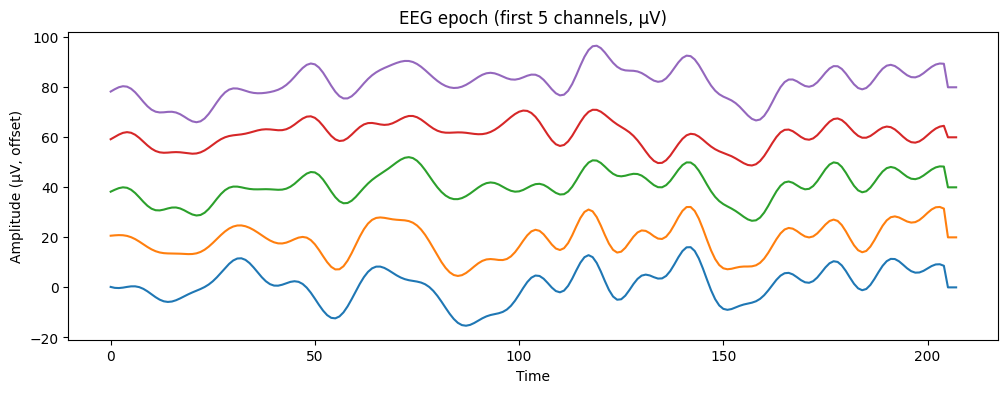

In [14]:
# визуализация
import matplotlib.pyplot as plt

epoch = sample[0]            # (14, 208)
epoch_uv = epoch * 1e6       # перевод в µV

plt.figure(figsize=(12,4))

offset = 20  # вертикальный offset между каналами

for c in range(5):
    plt.plot(epoch_uv[c] + c*offset)

plt.title("EEG epoch (first 5 channels, µV)")
plt.xlabel("Time")
plt.ylabel("Amplitude (µV, offset)")
plt.show()

## 3) Реализовать masking (time masking ~50%)

time-block masking

- маска по времени

- одинаковая для всех каналов

- contiguous сегменты

- mask_ratio ≈ 0.5

In [8]:
import numpy as np

def time_block_mask(x, mask_ratio=0.5, block_size=16):
    """
    x: (C, L)
    mask_ratio: доля времени для маски
    block_size: размер contiguous блока

    returns:
        x_masked
        mask (L,) 1 = masked
    """
    C, L = x.shape

    n_mask = int(L * mask_ratio)
    mask = np.zeros(L, dtype=np.float32)

    masked = 0
    while masked < n_mask:
        start = np.random.randint(0, L - block_size + 1)
        end = start + block_size

        newly = 1 - mask[start:end]
        mask[start:end] = 1
        masked += newly.sum()

    x_masked = x.copy()
    x_masked[:, mask == 1] = 0.0

    return x_masked, mask

In [15]:
# unit check mask ratio
x = sample[0]
x_masked, mask = time_block_mask(x)

print("Mask ratio:", mask.mean())

Mask ratio: 0.53846157


In [ ]:
# визуализация masking
import matplotlib.pyplot as plt

ch = 0

plt.figure(figsize=(12,4))
plt.plot(x[ch]*1e6, label="original")
plt.plot(x_masked[ch]*1e6, label="masked")
plt.legend()
plt.title("Masking example (µV)")
plt.show()

In [ ]:
# визуализация mask
plt.figure(figsize=(12,1))
plt.imshow(mask[None,:], aspect="auto", cmap="gray_r")
plt.title("Mask")
plt.yticks([])
plt.show()

In [16]:
def batch_time_block_mask(x, mask_ratio=0.5, block_size=16):
    """
    x: (B, C, L)
    returns:
        x_masked
        mask (B, L)
    """
    B, C, L = x.shape
    device = x.device

    mask = torch.zeros(B, L, device=device)

    n_mask = int(L * mask_ratio)

    for b in range(B):
        masked = 0
        while masked < n_mask:
            start = torch.randint(0, L - block_size + 1, (1,), device=device).item()
            end = start + block_size

            newly = 1 - mask[b, start:end]
            mask[b, start:end] = 1
            masked += newly.sum().item()

    # --- ВОТ КЛЮЧЕВОЕ ИСПРАВЛЕНИЕ ---
    mask_expanded = mask.unsqueeze(1)      # (B,1,L)
    x_masked = x * (1 - mask_expanded)     # zero masked region

    return x_masked, mask

## 4) Dataset / DataLoader

In [58]:
import numpy as np
import zarr
import torch
from torch.utils.data import Dataset

class SSLZarrDataset(Dataset):
    def __init__(self, zarr_path, max_samples=100_000, seed=2026):
        self.root = zarr.open(zarr_path, mode="r")
        self.X = self.root["X"]

        N = self.X.shape[0]
        rng = np.random.default_rng(seed)

        self.indices = rng.choice(
            N,
            size=min(max_samples, N),
            replace=False
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x = self.X[int(self.indices[idx])]
        x = np.asarray(x, dtype=np.float32)
        x = x * 1e6   # перевод в µV
        return torch.from_numpy(x)

In [59]:
# Проверка
dataset = SSLZarrDataset(zarr_path, max_samples=100_000
)

print("Len:", len(dataset))


Len: 100000


In [60]:
# DataLoader
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [21]:
# Проверка
batch = next(iter(loader))

x_masked, x, mask = batch

print(x_masked.shape)
print(x.shape)
print(mask.shape)

ValueError: too many values to unpack (expected 3)

In [ ]:
batch = next(iter(loader))

## 5) Модель: 1D U-Net (encoder + decoder)

In [25]:
import torch
import torch.nn as nn

class DoubleConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool1d(kernel_size=2, stride=2),
            DoubleConv1D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up1D(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.bilinear = bilinear

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="linear", align_corners=True)
            mid_channels = in_channels // 2
            self.conv = DoubleConv1D(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose1d(in_channels, out_channels, kernel_size=2, stride=2)
            self.conv = DoubleConv1D(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: низ, x2: skip
        x1 = self.up(x1)

        # подгоняем длину, если не совпадает
        diff = x2.size(-1) - x1.size(-1)
        if diff > 0:
            x1 = nn.functional.pad(x1, (diff // 2, diff - diff // 2))
        elif diff < 0:
            x2 = nn.functional.pad(x2, (-diff // 2, -diff - (-diff // 2)))

        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet1D_Light(nn.Module):
    """
    U-Net 1D с 4 уровнями даунсемплинга, вдохновлён Hong et al., 2025.
    Каналы: 32 → 64 → 128 → 256, bottleneck 512.
    """
    def __init__(self, n_channels, n_classes, base_ch=32, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        ch1 = base_ch
        ch2 = base_ch * 2
        ch3 = base_ch * 4
        ch4 = base_ch * 8
        bottleneck_ch = base_ch * 16  # 512 при base_ch=32

        # encoder
        self.inc = DoubleConv1D(n_channels, ch1)
        self.down1 = Down1D(ch1, ch2)
        self.down2 = Down1D(ch2, ch3)
        self.down3 = Down1D(ch3, ch4)
        self.down4 = Down1D(ch4, bottleneck_ch)

        # decoder
        self.up1 = Up1D(bottleneck_ch + ch4, ch4, bilinear)
        self.up2 = Up1D(ch4 + ch3, ch3, bilinear)
        self.up3 = Up1D(ch3 + ch2, ch2, bilinear)
        self.up4 = Up1D(ch2 + ch1, ch1, bilinear)
        self.outc = OutConv1D(ch1, n_classes)

    def encode(self, x):
        x1 = self.inc(x)     # (N, ch1, L)
        x2 = self.down1(x1)  # (N, ch2, L/2)
        x3 = self.down2(x2)  # (N, ch3, L/4)
        x4 = self.down3(x3)  # (N, ch4, L/8)
        x5 = self.down4(x4)  # (N, bottleneck_ch, L/16)
        return x1, x2, x3, x4, x5

    def decode(self, x1, x2, x3, x4, x5):
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encode(x)
        logits = self.decode(x1, x2, x3, x4, x5)
        return logits, x5  # x5 — bottleneck

In [61]:

device = "cuda"

model = UNet1D_Light(n_channels=14, n_classes=14)
model = model.to(device)

print("Model ready")

Model ready


In [62]:
# Проверка
x_masked, x, mask = next(iter(loader))
x_masked = x_masked.to(device)

with torch.no_grad():
    recon, z = model(x_masked)

print("Recon:", recon.shape)
print("Bottleneck:", z.shape)

ValueError: too many values to unpack (expected 3)

## 6) Loss

In [66]:
# masked loss функция
import torch
import torch.nn.functional as F

def masked_l1_loss(recon, target, mask):
    """
    recon:  (B, C, L)
    target: (B, C, L)
    mask:   (B, L)  1 = masked
    """

    mask = mask.unsqueeze(1)          # (B,1,L)
    mask = mask.expand_as(recon)      # (B,C,L)

    loss = torch.abs(recon - target)
    loss = loss * mask

    return loss.sum() / mask.sum()

In [64]:
# sanity check
x_masked, x, mask = next(iter(loader))

x_masked = x_masked.to(device)
x = x.to(device)
mask = mask.to(device)

with torch.no_grad():
    recon, _ = model(x_masked)

loss = masked_l1_loss(recon, x, mask)

print(loss)

ValueError: too many values to unpack (expected 3)

In [65]:
# Проверка
zero_mask = torch.zeros_like(mask)
print(masked_l1_loss(recon, x, zero_mask))

tensor(nan, device='cuda:0')


## 7) Optimizer + Scheduler

In [67]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [68]:
# scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

## 8) Training loop (AMP + scheduler)

In [69]:
scaler = torch.amp.GradScaler("cuda")

In [70]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0
    n = 0

    for x in tqdm(loader):
        # --- 1. перенос на GPU ---
        x = x.to(device, non_blocking=True)

        # --- 2. masking теперь тут ---
        x_masked, mask = batch_time_block_mask(x)

        optimizer.zero_grad()

        # --- 3. forward ---
        with torch.amp.autocast("cuda"):
            recon, _ = model(x_masked)
            loss = masked_l1_loss(recon, x, mask)

        # --- 4. backward ---
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n += 1

        # occasional logging
        if n % 100 == 0:
            print("batch loss:", loss.item())

    return total_loss / n

## 9) Валидация для SSL (лёгкая)

In [71]:
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch} =====")

    loss = train_one_epoch(model, loader, optimizer, device)
    scheduler.step()

    print(f"Epoch {epoch} mean loss: {loss:.6f}")

    # checkpoint
    torch.save(
        model.state_dict(),
        f"/kaggle/working/unet_ssl_epoch{epoch}_02.pt"
    )


===== Epoch 0 =====


  6%|▋         | 101/1563 [00:36<08:02,  3.03it/s]

batch loss: 12.022587776184082


 13%|█▎        | 201/1563 [01:13<07:30,  3.02it/s]

batch loss: 13.281052589416504


...

batch loss: 5.843209743499756


 96%|█████████▌| 1500/1563 [09:06<00:22,  2.85it/s]

batch loss: 4.979337692260742


100%|██████████| 1563/1563 [09:28<00:00,  2.75it/s]

Epoch 9 mean loss: 6.368538


## 10) Быстрая визуальная проверка реконструкций

In [72]:
print("orig min/max:", orig.min(), orig.max())
print("recon min/max:", reconstructed.min(), reconstructed.max())

orig min/max: -2.3538165e-05 2.1500126e-05
recon min/max: 8.827448e-05 0.0018418282


In [73]:
model.eval()

x = next(iter(loader)).to(device)
x_masked, mask = batch_time_block_mask(x)

with torch.no_grad():
    recon, z = model(x_masked)

# возьмём первый пример и первый канал
orig = x[0, 0].cpu().numpy()
masked = x_masked[0, 0].cpu().numpy()
reconstructed = recon[0, 0].cpu().numpy()
mask_np = mask[0].cpu().numpy()

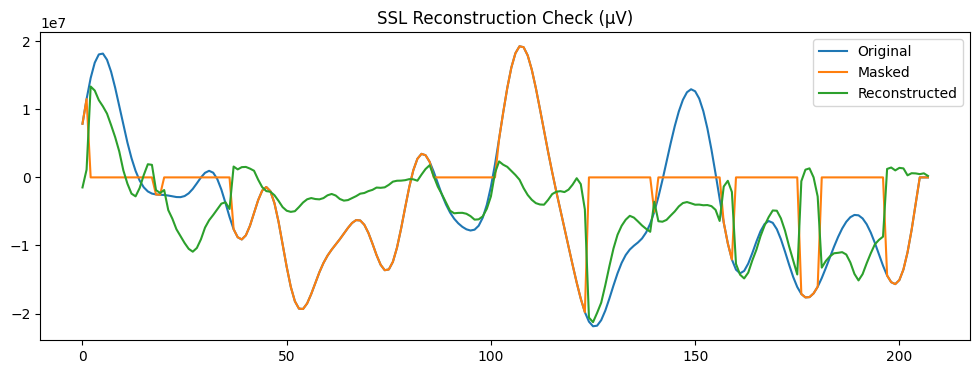

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(orig * 1e6, label="Original")
plt.plot(masked * 1e6, label="Masked")
plt.plot(reconstructed * 1e6, label="Reconstructed")
plt.legend()
plt.title("SSL Reconstruction Check (µV)")
plt.show()

In [76]:
print("Bottleneck shape:", z.shape)

Bottleneck shape: torch.Size([64, 512, 13])


## 10) Артефакты на выходе

In [79]:
# Сохранить энкодер отдельно
torch.save(
    {
        "inc": model.inc.state_dict(),
        "down1": model.down1.state_dict(),
        "down2": model.down2.state_dict(),
        "down3": model.down3.state_dict(),
        "down4": model.down4.state_dict(),
    },
    "/kaggle/working/encoder_ssl_02.pt"
)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/unet_ssl_final_v2.pt")